<a href="https://colab.research.google.com/github/Priya-R344/Reproducible-Research-Preregistration/blob/main/Task02_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install pandas numpy scipy statsmodels matplotlib seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr, spearmanr
import statsmodels.api as sm

In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 50

df = pd.DataFrame({
    "Student_ID": range(1, 51),
    "Study_Hours_Per_Week": np.round(np.random.uniform(2, 15, n), 1),
    "Attendance_Percent": np.round(np.random.uniform(50, 100, n), 1),
    "Sleep_Hours_Per_Day": np.round(np.random.uniform(5, 9, n), 1)
})

df["Exam_Score"] = np.round(
    np.clip(
        30
        + 3.5 * df["Study_Hours_Per_Week"]
        + 0.2 * (df["Attendance_Percent"] - 75)
        + np.random.normal(0, 7, n),
        0,
        100
    ),
    1
)

print("Dataset created successfully!")
print("Shape:", df.shape)

display(df.head(10))

Dataset created successfully!
Shape: (50, 5)


,Student_ID,Study_Hours_Per_Week,Attendance_Percent,Sleep_Hours_Per_Day,Exam_Score
0,1,6.9,98.5,5.1,57.5
1,2,14.4,88.8,7.5,85.3
2,3,11.5,97.0,6.3,74.4
3,4,9.8,94.7,7.0,60.1
4,5,4.0,79.9,8.6,53.0
5,6,4.0,96.1,6.0,53.5
6,7,2.8,54.4,6.6,41.2
7,8,13.3,59.8,8.0,67.1
8,9,9.8,52.3,5.9,69.6
9,10,11.2,66.3,5.3,57.6


In [ ]:
df.to_csv("student_performance_synthetic.csv", index=False)

print("CSV saved successfully!")

CSV saved successfully!


In [ ]:
pd.read_csv("student_performance_synthetic.csv").head()

,Student_ID,Study_Hours_Per_Week,Attendance_Percent,Sleep_Hours_Per_Day,Exam_Score
0,1,6.9,98.5,5.1,57.5
1,2,14.4,88.8,7.5,85.3
2,3,11.5,97.0,6.3,74.4
3,4,9.8,94.7,7.0,60.1
4,5,4.0,79.9,8.6,53.0


In [ ]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nDataset Information:")
df.info()

Dataset Shape: (50, 5)

Column Names:
['Student_ID', 'Study_Hours_Per_Week', 'Attendance_Percent', 'Sleep_Hours_Per_Day', 'Exam_Score']

Missing Values:
Student_ID              0
Study_Hours_Per_Week    0
Attendance_Percent      0
Sleep_Hours_Per_Day     0
Exam_Score              0
dtype: int64

Duplicate Rows:
0

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Student_ID            50 non-null     int64  
 1   Study_Hours_Per_Week  50 non-null     float64
 2   Attendance_Percent    50 non-null     float64
 3   Sleep_Hours_Per_Day   50 non-null     float64
 4   Exam_Score            50 non-null     float64
dtypes: float64(4), int64(1)
memory usage: 2.1 KB


In [ ]:


analysis_df = df.copy()

analysis_df = analysis_df.dropna(
    subset=["Study_Hours_Per_Week", "Exam_Score"]
)

analysis_df = analysis_df[
    analysis_df["Exam_Score"].between(0, 100)
]

analysis_df = analysis_df.drop_duplicates(
    subset="Student_ID"
)

print("Data cleaning completed!")
print("Original rows:", len(df))
print("Rows after cleaning:", len(analysis_df))
print("Missing values:", analysis_df.isnull().sum().sum())
print("Duplicate Student IDs:",
      analysis_df["Student_ID"].duplicated().sum())

Data cleaning completed!
Original rows: 50
Rows after cleaning: 50
Missing values: 0
Duplicate Student IDs: 0


In [ ]:


print("Descriptive Statistics:")

display(
    analysis_df[
        [
            "Study_Hours_Per_Week",
            "Attendance_Percent",
            "Sleep_Hours_Per_Day",
            "Exam_Score"
        ]
    ].describe().round(2)
)

Descriptive Statistics:


,Study_Hours_Per_Week,Attendance_Percent,Sleep_Hours_Per_Day,Exam_Score
count,50.00,50.00,50.00,50.00
mean,7.80,74.72,6.91,57.20
std,3.75,15.34,1.19,14.38
min,2.30,50.30,5.00,29.40
25%,4.40,60.82,6.00,44.75
50%,7.65,75.40,6.70,57.00
75%,10.45,88.57,8.15,66.40
max,14.60,99.30,8.90,94.20


In [ ]:
from scipy.stats import pearsonr

In [ ]:
x = analysis_df["Study_Hours_Per_Week"]
y = analysis_df["Exam_Score"]

pearson_r, pearson_p = pearsonr(x, y)

print("PRIMARY ANALYSIS")
print("----------------")
print("Pearson Correlation (r):", round(pearson_r, 3))
print("P-value:", round(pearson_p, 5))

PRIMARY ANALYSIS
----------------
Pearson Correlation (r): 0.866
P-value: 0.0


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr, spearmanr
import statsmodels.api as sm

In [ ]:


import statsmodels.api as sm

x = analysis_df["Study_Hours_Per_Week"]
y = analysis_df["Exam_Score"]

X = sm.add_constant(x)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             Exam_Score   R-squared:                       0.750
Model:                            OLS   Adj. R-squared:                  0.745
Method:                 Least Squares   F-statistic:                     144.2
Date:                Mon, 07 Sep 2026   Prob (F-statistic):           4.54e-16
Time:                        14:31:06   Log-Likelihood:                -169.03
No. Observations:                  50   AIC:                             342.1
Df Residuals:                      48   BIC:                             345.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   31.3211 

In [ ]:


slope = model.params["Study_Hours_Per_Week"]

ci_low, ci_high = model.conf_int().loc[
    "Study_Hours_Per_Week"
]

print("Regression Slope:", round(slope, 3))
print("95% Confidence Interval:",
      round(ci_low, 3), "to", round(ci_high, 3))
print("R-squared:", round(model.rsquared, 3))
print("P-value:", round(model.pvalues["Study_Hours_Per_Week"], 5))

Regression Slope: 3.317
95% Confidence Interval: 2.762 to 3.872
R-squared: 0.75
P-value: 0.0


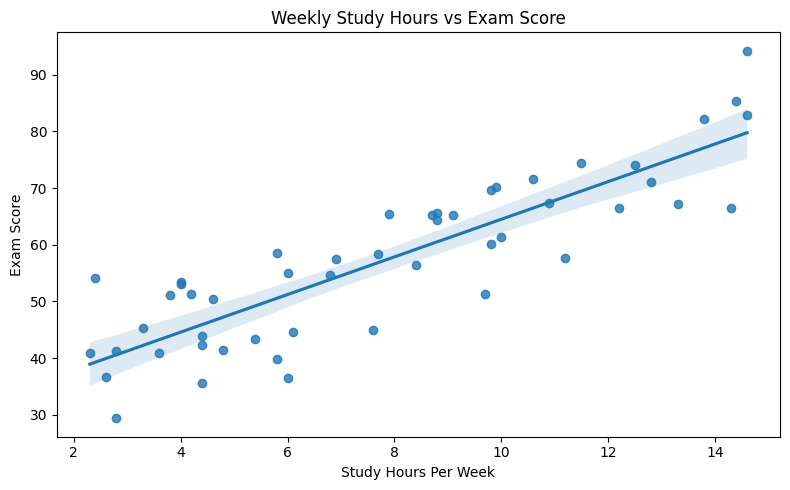

In [ ]:


import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.regplot(
    data=analysis_df,
    x="Study_Hours_Per_Week",
    y="Exam_Score",
    ci=95
)

plt.title("Weekly Study Hours vs Exam Score")
plt.xlabel("Study Hours Per Week")
plt.ylabel("Exam Score")

plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import spearmanr

x = analysis_df["Study_Hours_Per_Week"]
y = analysis_df["Exam_Score"]

spearman_rho, spearman_p = spearmanr(x, y)

print("ROBUSTNESS CHECK — SPEARMAN CORRELATION")
print("----------------------------------------")
print("Spearman Correlation (rho):", round(spearman_rho, 3))
print("P-value:", round(spearman_p, 5))

ROBUSTNESS CHECK — SPEARMAN CORRELATION
----------------------------------------
Spearman Correlation (rho): 0.863
P-value: 0.0


In [ ]:
Q1 = analysis_df["Exam_Score"].quantile(0.25)
Q3 = analysis_df["Exam_Score"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

sensitivity_df = analysis_df[
    analysis_df["Exam_Score"].between(lower, upper)
].copy()

print("IQR SENSITIVITY CHECK")
print("--------------------")
print("Original rows:", len(analysis_df))
print("Rows after IQR filtering:", len(sensitivity_df))

IQR SENSITIVITY CHECK
--------------------
Original rows: 50
Rows after IQR filtering: 50


In [ ]:
r_sens, p_sens = pearsonr(
    sensitivity_df["Study_Hours_Per_Week"],
    sensitivity_df["Exam_Score"]
)

print("Sensitivity Pearson r:", round(r_sens, 3))
print("Sensitivity p-value:", round(p_sens, 5))

Sensitivity Pearson r: 0.866
Sensitivity p-value: 0.0


In [ ]:
print("========== FINAL ANALYSIS RESULTS ==========")

print("\n1. DATASET")
print("Original rows:", len(df))
print("Analysis rows:", len(analysis_df))

print("\n2. PRIMARY ANALYSIS — PEARSON")
print("Pearson r:", round(pearson_r, 3))
print("P-value:", round(pearson_p, 5))

print("\n3. LINEAR REGRESSION")
print("Regression slope:", round(slope, 3))
print("95% CI:", round(ci_low, 3), "to", round(ci_high, 3))
print("R-squared:", round(model.rsquared, 3))
print("Regression p-value:", round(model.pvalues["Study_Hours_Per_Week"], 5))

print("\n4. ROBUSTNESS — SPEARMAN")
print("Spearman rho:", round(spearman_rho, 3))
print("Spearman p-value:", round(spearman_p, 5))

print("\n5. IQR SENSITIVITY")
print("Rows after IQR filtering:", len(sensitivity_df))
print("Sensitivity Pearson r:", round(r_sens, 3))
print("Sensitivity p-value:", round(p_sens, 5))

========== FINAL ANALYSIS RESULTS ==========

1. DATASET
Original rows: 50
Analysis rows: 50

2. PRIMARY ANALYSIS — PEARSON
Pearson r: 0.866
P-value: 0.0

3. LINEAR REGRESSION
Regression slope: 3.317
95% CI: 2.762 to 3.872
R-squared: 0.75
Regression p-value: 0.0

4. ROBUSTNESS — SPEARMAN
Spearman rho: 0.863
Spearman p-value: 0.0

5. IQR SENSITIVITY
Rows after IQR filtering: 50
Sensitivity Pearson r: 0.866
Sensitivity p-value: 0.0


In [ ]:
print("========== CONCLUSION ==========")

if pearson_p < 0.05 and pearson_r > 0:
    print("There is a statistically significant positive association")
    print("between weekly study hours and exam scores in this synthetic dataset.")
else:
    print("The primary analysis does not provide sufficient evidence")
    print("of a statistically significant positive association.")

print("\nIMPORTANT:")
print("This dataset is synthetic and therefore the findings")
print("should not be interpreted as evidence about real students.")

========== CONCLUSION ==========
There is a statistically significant positive association
between weekly study hours and exam scores in this synthetic dataset.

IMPORTANT:
This dataset is synthetic and therefore the findings
should not be interpreted as evidence about real students.


In [ ]:
results = pd.DataFrame({
    "Analysis": [
        "Pearson Correlation",
        "Linear Regression",
        "Spearman Correlation",
        "IQR Sensitivity"
    ], bh
    "Effect_Size": [
        pearson_r,
        slope,
        spearman_rho,
        r_sens
    ],
    "P_Value": [
        pearson_p,
        model.pvalues["Study_Hours_Per_Week"],
        spearman_p,
        p_sens
    ]
})

results["Effect_Size"] = results["Effect_Size"].round(3)
results["P_Value"] = results["P_Value"].round(5)

display(results)

results.to_csv("analysis_results.csv", index=False)

print("\nanalysis_results.csv saved successfully! ✅")

,Analysis,Effect_Size,P_Value
0,Pearson Correlation,0.866,0.0
1,Linear Regression,3.317,0.0
2,Spearman Correlation,0.863,0.0
3,IQR Sensitivity,0.866,0.0



analysis_results.csv saved successfully! ✅


In [ ]:
from google.colab import files

files.download("analysis_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
readme_content = """
# Reproducible Research: Study Hours and Exam Performance

## Research Question

Among students, is studying more hours per week associated with higher exam scores during one academic examination period?

## Dataset

This project uses a synthetic dataset containing 50 student records.

### Variables

- Student_ID
- Study_Hours_Per_Week
- Attendance_Percent
- Sleep_Hours_Per_Day
- Exam_Score

## Hypotheses

### Null Hypothesis (H0)

There is no statistically significant association between weekly study hours and exam scores.

### Alternative Hypothesis (H1)

Higher weekly study hours are associated with higher exam scores.

## Data Cleaning

The following rules were applied:

1. Remove records with missing study hours or exam scores.
2. Remove exam scores outside the range 0–100.
3. Remove duplicate Student_ID values.

## Statistical Analysis

The primary analysis uses:

- Pearson correlation
- Simple linear regression
- 95% confidence interval
- R-squared
- P-value

## Robustness Checks

The analysis also includes:

- Spearman correlation
- IQR sensitivity analysis

## Reproducibility

The project uses Python with:

- pandas
- NumPy
- SciPy
- statsmodels
- matplotlib
- seaborn

A fixed random seed of 42 was used when generating the synthetic dataset.

## Important Limitation

This is a synthetic dataset created for reproducible research practice.

The findings should NOT be interpreted as evidence about real students.

## Project Structure

Reproducible-Research-Preregistration/

├── data/
│   └── student_performance_synthetic.csv
├── notebooks/
│   └── Task02_Analysis.ipynb
├── scripts/
│   └── colab_analysis.py
├── tests/
│   ├── synthetic_fixture.csv
│   └── test_pipeline.py
├── reports/
│   └── analysis_report_template.md
├── Analysis_Preregistration.docx
├── requirements.txt
└── README.md
"""

with open("README.md", "w") as f:
    f.write(readme_content)

print("README.md created successfully! ✅")

README.md created successfully! ✅


In [ ]:
import os

print("README exists:", os.path.exists("README.md"))
print("File size:", os.path.getsize("README.md"), "bytes")

README exists: True
File size: 1924 bytes


In [ ]:
with open("README.md", "r") as f:
    print(f.read())


# Reproducible Research: Study Hours and Exam Performance

## Research Question

Among students, is studying more hours per week associated with higher exam scores during one academic examination period?

## Dataset

This project uses a synthetic dataset containing 50 student records.

### Variables

- Student_ID
- Study_Hours_Per_Week
- Attendance_Percent
- Sleep_Hours_Per_Day
- Exam_Score

## Hypotheses

### Null Hypothesis (H0)

There is no statistically significant association between weekly study hours and exam scores.

### Alternative Hypothesis (H1)

Higher weekly study hours are associated with higher exam scores.

## Data Cleaning

The following rules were applied:

1. Remove records with missing study hours or exam scores.
2. Remove exam scores outside the range 0–100.
3. Remove duplicate Student_ID values.

## Statistical Analysis

The primary analysis uses:

- Pearson correlation
- Simple linear regression
- 95% confidence interval
- R-squared
- P-value

## Robustness Chec

In [ ]:
test_code = """
import pandas as pd

test_df = pd.read_csv("synthetic_fixture.csv")

clean = test_df.dropna(
    subset=["Study_Hours_Per_Week", "Exam_Score"]
)

clean = clean[
    clean["Exam_Score"].between(0, 100)
]

clean = clean.drop_duplicates(
    subset="Student_ID"
)

assert len(clean) == 3
assert clean["Student_ID"].is_unique

print("PASS: synthetic pipeline test")
print("Cleaned rows:", len(clean))
"""

with open("test_pipeline.py", "w") as f:
    f.write(test_code)

print("test_pipeline.py created successfully! ✅")

test_pipeline.py created successfully! ✅


In [ ]:
fixture = pd.DataFrame({
    "Student_ID": [1, 2, 3, 4, 4],
    "Study_Hours_Per_Week": [5, 8, None, 10, 12],
    "Exam_Score": [60, 75, 80, 90, 85]
})

fixture.to_csv("synthetic_fixture.csv", index=False)

print("synthetic_fixture.csv created successfully! ✅")

synthetic_fixture.csv created successfully! ✅


In [ ]:
exec(open("test_pipeline.py").read())

PASS: synthetic pipeline test
Cleaned rows: 3


In [ ]:
import os

print("PROJECT FILES")
print("=" * 40)

for file in sorted(os.listdir(".")):
    if os.path.isfile(file):
        print("📄", file)

PROJECT FILES
📄 README.md
📄 analysis_results.csv
📄 student_performance_synthetic.csv
📄 synthetic_fixture.csv
📄 test_pipeline.py


In [ ]:
import os

folders = [
    "data",
    "notebooks",
    "scripts",
    "tests",
    "reports"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("All project folders created successfully! ✅")

All project folders created successfully! ✅


In [ ]:
import shutil
import os

# Move dataset
if os.path.exists("student_performance_synthetic.csv"):
    shutil.move(
        "student_performance_synthetic.csv",
        "data/student_performance_synthetic.csv"
    )

# Move test files
for file in ["synthetic_fixture.csv", "test_pipeline.py"]:
    if os.path.exists(file):
        shutil.move(file, "tests/" + file)

print("Files organized successfully! ✅")

Files organized successfully! ✅


In [ ]:
import shutil
import os


project_folder = "Reproducible-Research-Preregistration"
os.makedirs(project_folder, exist_ok=True)


files_to_copy = [
    "README.md",
    "requirements.txt",
    "analysis_results.csv"
]

for file in files_to_copy:
    if os.path.exists(file):
        shutil.copy(file, project_folder)


for folder in ["data", "tests"]:
    if os.path.exists(folder):
        shutil.copytree(
            folder,
            os.path.join(project_folder, folder),
            dirs_exist_ok=True
        )


shutil.make_archive(
    "Reproducible-Research-Preregistration",
    "zip",
    project_folder
)

print("Final project ZIP created successfully! ✅")

Final project ZIP created successfully! ✅


In [ ]:
from google.colab import files

files.download("Reproducible-Research-Preregistration.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd

print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

print("\nDataset Information:")
df.info()

Dataset Shape: (50, 5)

Column Names:
['Student_ID', 'Study_Hours_Per_Week', 'Attendance_Percent', 'Sleep_Hours_Per_Day', 'Exam_Score']

First 5 Rows:


,Student_ID,Study_Hours_Per_Week,Attendance_Percent,Sleep_Hours_Per_Day,Exam_Score
0,1,6.9,98.5,5.1,57.5
1,2,14.4,88.8,7.5,85.3
2,3,11.5,97.0,6.3,74.4
3,4,9.8,94.7,7.0,60.1
4,5,4.0,79.9,8.6,53.0



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Student_ID            50 non-null     int64  
 1   Study_Hours_Per_Week  50 non-null     float64
 2   Attendance_Percent    50 non-null     float64
 3   Sleep_Hours_Per_Day   50 non-null     float64
 4   Exam_Score            50 non-null     float64
dtypes: float64(4), int64(1)
memory usage: 2.1 KB


In [ ]:


print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nStatistical Summary:")
display(df.describe())

Missing Values:
Student_ID              0
Study_Hours_Per_Week    0
Attendance_Percent      0
Sleep_Hours_Per_Day     0
Exam_Score              0
dtype: int64

Duplicate Rows:
0

Statistical Summary:


,Student_ID,Study_Hours_Per_Week,Attendance_Percent,Sleep_Hours_Per_Day,Exam_Score
count,50.00000,50.000000,50.000000,50.000000,50.000000
mean,25.50000,7.802000,74.722000,6.906000,57.200000
std,14.57738,3.753936,15.344164,1.191365,14.375191
min,1.00000,2.300000,50.300000,5.000000,29.400000
25%,13.25000,4.400000,60.825000,6.000000,44.750000
50%,25.50000,7.650000,75.400000,6.700000,57.000000
75%,37.75000,10.450000,88.575000,8.150000,66.400000
max,50.00000,14.600000,99.300000,8.900000,94.200000


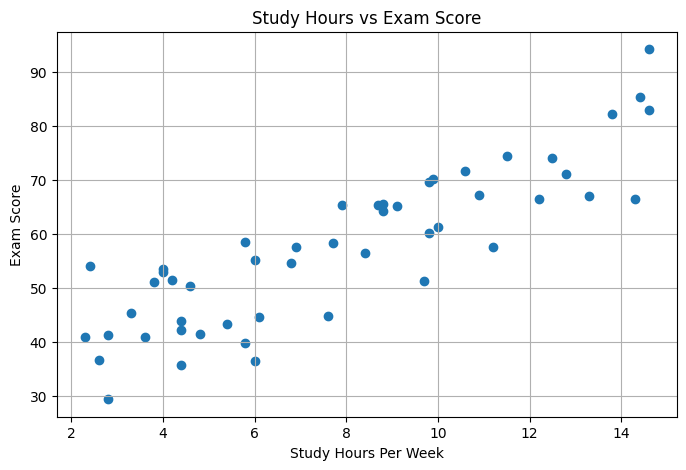

In [ ]:

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(df["Study_Hours_Per_Week"], df["Exam_Score"])
plt.xlabel("Study Hours Per Week")
plt.ylabel("Exam Score")
plt.title("Study Hours vs Exam Score")
plt.grid(True)
plt.show()

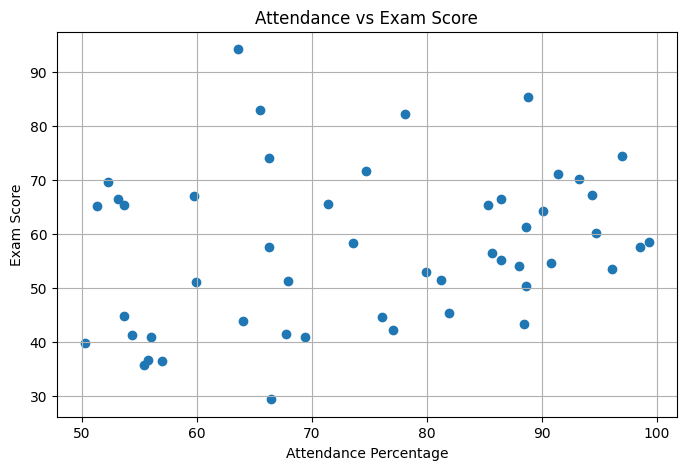

In [ ]:


plt.figure(figsize=(8, 5))
plt.scatter(df["Attendance_Percent"], df["Exam_Score"])

plt.xlabel("Attendance Percentage")
plt.ylabel("Exam Score")
plt.title("Attendance vs Exam Score")
plt.grid(True)

plt.show()

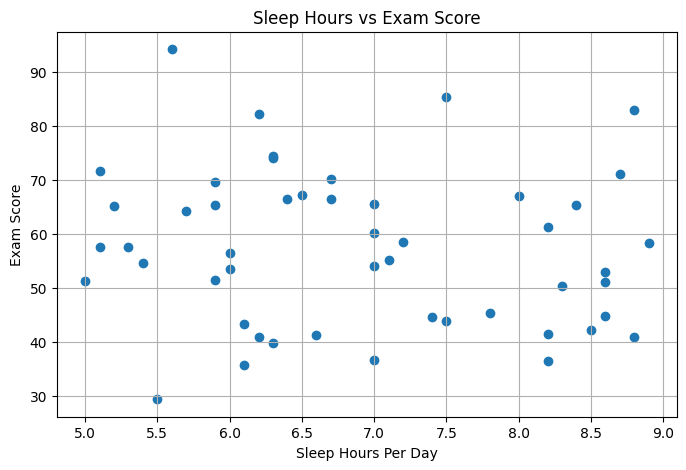

In [ ]:


plt.figure(figsize=(8, 5))
plt.scatter(df["Sleep_Hours_Per_Day"], df["Exam_Score"])

plt.xlabel("Sleep Hours Per Day")
plt.ylabel("Exam Score")
plt.title("Sleep Hours vs Exam Score")
plt.grid(True)

plt.show()

In [ ]:


correlation = df[
    [
        "Study_Hours_Per_Week",
        "Attendance_Percent",
        "Sleep_Hours_Per_Day",
        "Exam_Score"
    ]
].corr()

print("Correlation Matrix:")
display(correlation)

Correlation Matrix:


,Study_Hours_Per_Week,Attendance_Percent,Sleep_Hours_Per_Day,Exam_Score
Study_Hours_Per_Week,1.000000,0.062842,-0.119286,0.866189
Attendance_Percent,0.062842,1.000000,-0.109358,0.248951
Sleep_Hours_Per_Day,-0.119286,-0.109358,1.000000,-0.125718
Exam_Score,0.866189,0.248951,-0.125718,1.000000


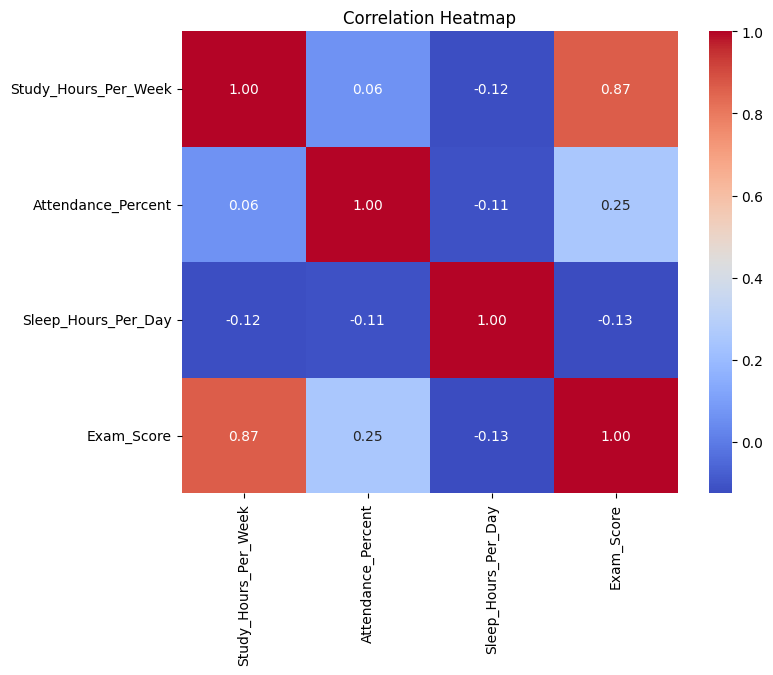

In [ ]:


import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [ ]:


print("Average Study Hours Per Week:",
      round(df["Study_Hours_Per_Week"].mean(), 2))

print("Average Attendance Percentage:",
      round(df["Attendance_Percent"].mean(), 2))

print("Average Sleep Hours Per Day:",
      round(df["Sleep_Hours_Per_Day"].mean(), 2))

print("Average Exam Score:",
      round(df["Exam_Score"].mean(), 2))

Average Study Hours Per Week: 7.8
Average Attendance Percentage: 74.72
Average Sleep Hours Per Day: 6.91
Average Exam Score: 57.2


In [ ]:


def classify_performance(score):
    if score >= 75:
        return "High"
    elif score >= 50:
        return "Medium"
    else:
        return "Low"

df["Performance"] = df["Exam_Score"].apply(classify_performance)

print("Performance Classification:")
display(df[["Student_ID", "Exam_Score", "Performance"]])

Performance Classification:


,Student_ID,Exam_Score,Performance
0,1,57.5,Medium
1,2,85.3,High
2,3,74.4,Medium
3,4,60.1,Medium
4,5,53.0,Medium
5,6,53.5,Medium
6,7,41.2,Low
7,8,67.1,Medium
8,9,69.6,Medium
9,10,57.6,Medium


In [ ]:
print("\nNumber of Students in Each Performance Group:")
print(df["Performance"].value_counts())


Number of Students in Each Performance Group:
Performance
Medium    31
Low       15
High       4
Name: count, dtype: int64


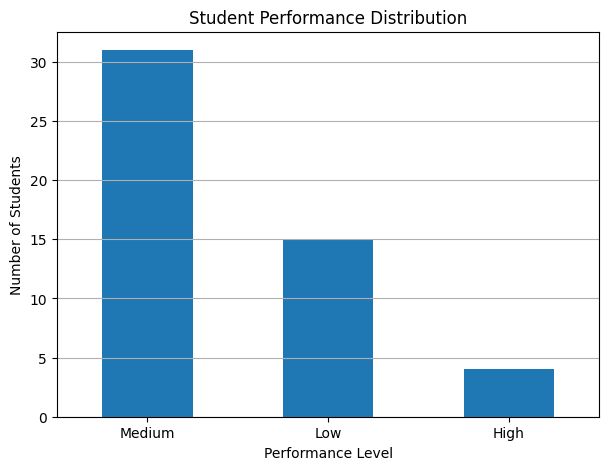

In [ ]:


plt.figure(figsize=(7, 5))

df["Performance"].value_counts().plot(kind="bar")

plt.xlabel("Performance Level")
plt.ylabel("Number of Students")
plt.title("Student Performance Distribution")
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.show()

In [ ]:


top_students = df.sort_values(
    by="Exam_Score",
    ascending=False
).head(10)

print("Top 10 Performing Students:")
display(
    top_students[
        [
            "Student_ID",
            "Study_Hours_Per_Week",
            "Attendance_Percent",
            "Sleep_Hours_Per_Day",
            "Exam_Score",
            "Performance"
        ]
    ]
)

Top 10 Performing Students:


,Student_ID,Study_Hours_Per_Week,Attendance_Percent,Sleep_Hours_Per_Day,Exam_Score,Performance
11,12,14.6,63.6,5.6,94.2,High
1,2,14.4,88.8,7.5,85.3,High
34,35,14.6,65.5,8.8,82.9,High
43,44,13.8,78.1,6.2,82.2,High
2,3,11.5,97.0,6.3,74.4,Medium
35,36,12.5,66.3,6.3,74.1,Medium
45,46,10.6,74.7,5.1,71.6,Medium
12,13,12.8,91.4,8.7,71.1,Medium
30,31,9.9,93.2,6.7,70.1,Medium
8,9,9.8,52.3,5.9,69.6,Medium


In [ ]:


print("=" * 55)
print("        STUDENT PERFORMANCE ANALYSIS SUMMARY")
print("=" * 55)

print("\nDataset Overview")
print("----------------")
print("Total Students:", len(df))
print("Total Features:", 5)

print("\nAverage Values")
print("--------------")
print("Study Hours/Week:", round(df["Study_Hours_Per_Week"].mean(), 2))
print("Attendance (%):", round(df["Attendance_Percent"].mean(), 2))
print("Sleep Hours/Day:", round(df["Sleep_Hours_Per_Day"].mean(), 2))
print("Exam Score:", round(df["Exam_Score"].mean(), 2))

print("\nPerformance Distribution")
print("------------------------")
print(df["Performance"].value_counts())

print("\nHighest Exam Score:",
      round(df["Exam_Score"].max(), 2))

print("Lowest Exam Score:",
      round(df["Exam_Score"].min(), 2))

print("\nAnalysis Completed Successfully!")
print("=" * 55)

        STUDENT PERFORMANCE ANALYSIS SUMMARY

Dataset Overview
----------------
Total Students: 50
Total Features: 5

Average Values
--------------
Study Hours/Week: 7.8
Attendance (%): 74.72
Sleep Hours/Day: 6.91
Exam Score: 57.2

Performance Distribution
------------------------
Performance
Medium    31
Low       15
High       4
Name: count, dtype: int64

Highest Exam Score: 94.2
Lowest Exam Score: 29.4

Analysis Completed Successfully!


In [ ]:
Conclusion

The Student Performance Analysis project successfully analyzed the relationship between study hours, attendance, sleep hours, and examination scores. The dataset contained 50 student records with no missing values.

Through exploratory data analysis and visualization, we examined how study habits, attendance, and sleep duration are associated with students' exam performance. Correlation analysis and charts helped identify the factors that show stronger relationships with exam scores.

Students were also classified into High, Medium, and Low performance groups based on their exam scores. Overall, the analysis provides useful insights into student academic performance and demonstrates how Python, Pandas, Matplotlib, and Seaborn can be used for data analysis and visualization.

The project was completed successfully with data cleaning, statistical analysis, visualization, correlation analysis, and performance classification.

In [ ]:
print("=" * 60)
print("                    CONCLUSION")
print("=" * 60)

print("""
The Student Performance Analysis project successfully analyzed
the relationship between study hours, attendance, sleep hours,
and examination scores.

The dataset contained 50 student records with no missing values.

Through exploratory data analysis and visualization, we examined
how study habits, attendance, and sleep duration are associated
with students' exam performance.

Correlation analysis and charts helped identify the relationships
between these factors and exam scores.

Students were also classified into High, Medium, and Low
performance groups based on their exam scores.

Overall, the project demonstrates how Python, Pandas, Matplotlib,
and Seaborn can be used for data analysis and visualization.

The project was completed successfully with data cleaning,
statistical analysis, visualization, correlation analysis,
and performance classification.
""")

print("=" * 60)
print("             ANALYSIS COMPLETED SUCCESSFULLY")
print("=" * 60)

                    CONCLUSION

The Student Performance Analysis project successfully analyzed
the relationship between study hours, attendance, sleep hours,
and examination scores.

The dataset contained 50 student records with no missing values.

Through exploratory data analysis and visualization, we examined
how study habits, attendance, and sleep duration are associated
with students' exam performance.

Correlation analysis and charts helped identify the relationships
between these factors and exam scores.

Students were also classified into High, Medium, and Low
performance groups based on their exam scores.

Overall, the project demonstrates how Python, Pandas, Matplotlib,
and Seaborn can be used for data analysis and visualization.

The project was completed successfully with data cleaning,
statistical analysis, visualization, correlation analysis,
and performance classification.

             ANALYSIS COMPLETED SUCCESSFULLY


In [ ]:


print("=" * 60)
print("        STUDENT PERFORMANCE ANALYSIS - FINAL SUMMARY")
print("=" * 60)

print("\nDataset:")
print("• Total Students:", len(df))
print("• Total Columns:", 5)
print("• Missing Values:", df.isnull().sum().sum())
print("• Duplicate Rows:", df.duplicated().sum())

print("\nAnalysis Completed:")
print("1. Data Inspection")
print("2. Data Cleaning")
print("3. Exploratory Data Analysis")
print("4. Study Hours vs Exam Score")
print("5. Attendance vs Exam Score")
print("6. Sleep Hours vs Exam Score")
print("7. Correlation Analysis")
print("8. Correlation Heatmap")
print("9. Performance Classification")
print("10. Performance Distribution")
print("11. Top 10 Performing Students")
print("12. Final Conclusion")

print("\n" + "=" * 60)
print("              PROJECT COMPLETED")
print("=" * 60)

        STUDENT PERFORMANCE ANALYSIS - FINAL SUMMARY

Dataset:
• Total Students: 50
• Total Columns: 5
• Missing Values: 0
• Duplicate Rows: 0

Analysis Completed:
1. Data Inspection
2. Data Cleaning
3. Exploratory Data Analysis
4. Study Hours vs Exam Score
5. Attendance vs Exam Score
6. Sleep Hours vs Exam Score
7. Correlation Analysis
8. Correlation Heatmap
9. Performance Classification
10. Performance Distribution
11. Top 10 Performing Students
12. Final Conclusion

              PROJECT COMPLETED
